In [1]:
import numpy as np
import random
from multiprocessing import Pool
import pandas as pd
from scipy.interpolate import interp1d
from scipy.special import gamma, erf
import scipy.stats as stats
from scipy.stats import binom

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager
font_manager.fontManager.addfont('/home/vvelan/DarkLim/examples/styles/Times_New_Roman.ttf')

mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = 'Times New Roman'
plt.rcParams['mathtext.fontset'] = 'stix'
plt.style.use('/home/vvelan/DarkLim/examples/styles/Style.mplstyle')

import sys
sys.path.insert(0, 'ExistingLimits/')
#import MichaelLimits as ML

import darklim
sys.path.insert(0, '/home/vvelan/DarkELF/')
import darkelf

import qetpy
import detprocess
import h5py
import time
import pickle
import glob

%matplotlib inline


# ER Signal Spectra

 .... Loading files for GaAs
Loaded GaAs_mermin.dat for epsilon in electron regime
electronic ELF taken or calculated from Y. Tu, C. Kwei and C. Tung,Angular and energy dependences of the surface excitation parameter for semiconducting iii–v compounds, Surface Science601(2007) 865.
phonon ELF taken or calculated from H.M. Lawler and E.L. Shirley, Anharmonic effects on infrared spectra of GaAs and gap:  First-principles calculations, Phys. Rev. B70(2004) 245209 and E.D. Palik, Gallium arsenide (gaas), in Handbook of Optical Constants of Solids, E.D. Palik, ed.,pp. 429–443, Elsevier (1985).
Loaded GaAs_epsphonon_data10K.dat for epsilon in phonon regime
Warning! Atomic Migdal calculation not present
Warning! Momentum dependent Zion for Migdal calculation not loaded. Using Z - number of valence electrons.
Loaded /home/vvelan/DarkELF/darkelf/../data/GaAs/Ga_pDoS.dat for partial densities of states
Loaded /home/vvelan/DarkELF/darkelf/../data/GaAs/As_pDoS.dat for partial densities of states
L

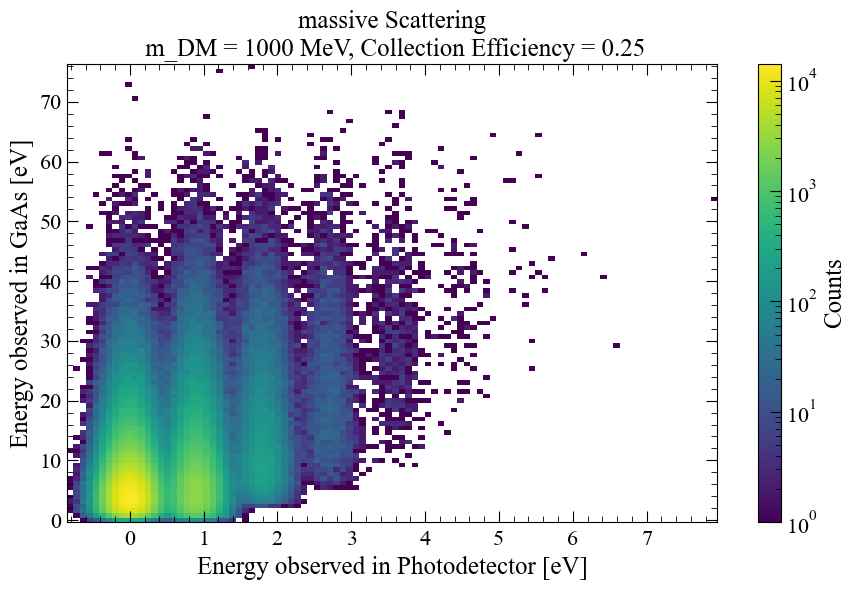

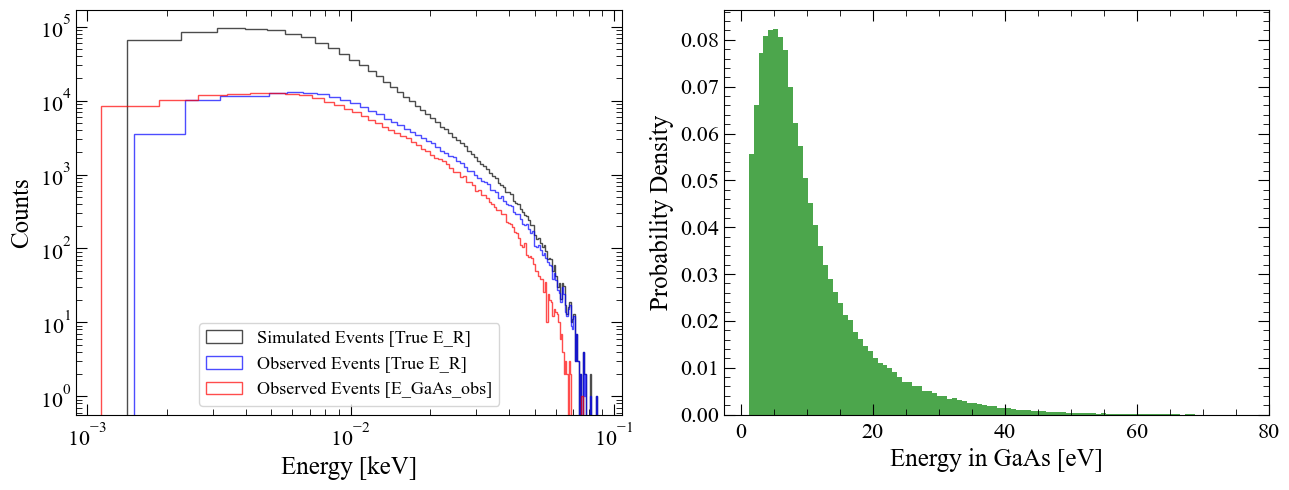

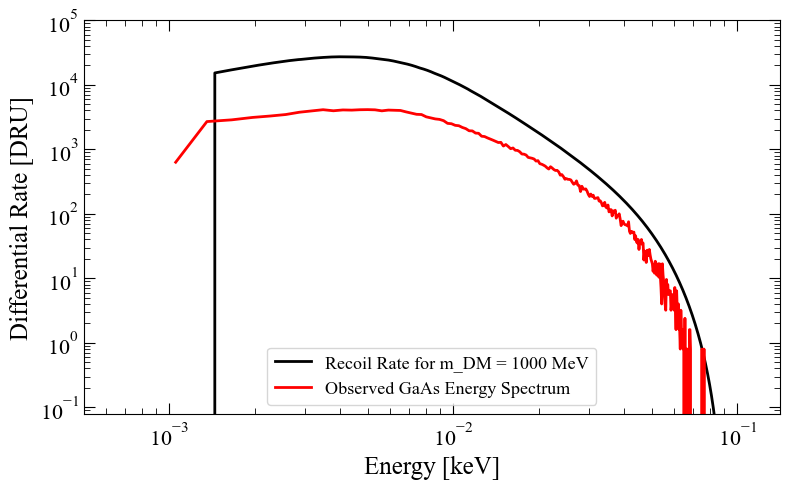

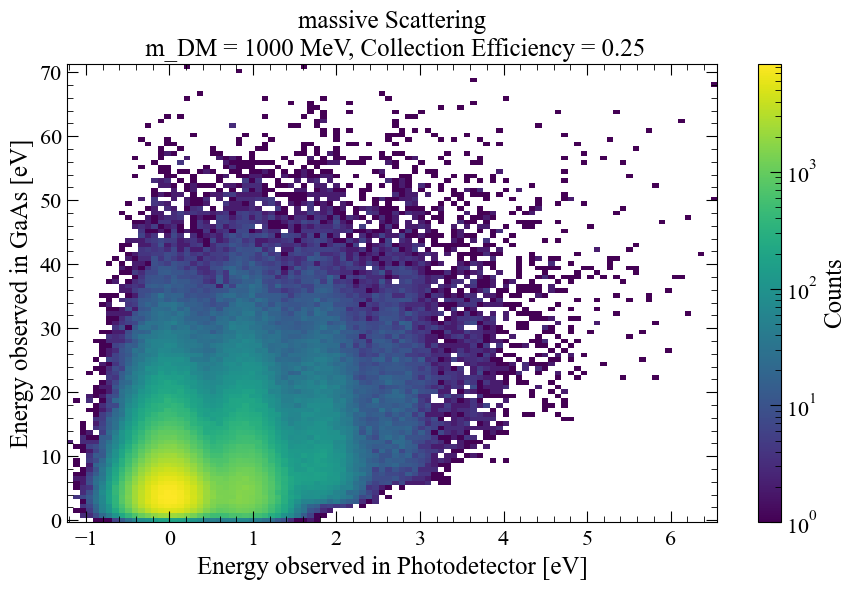

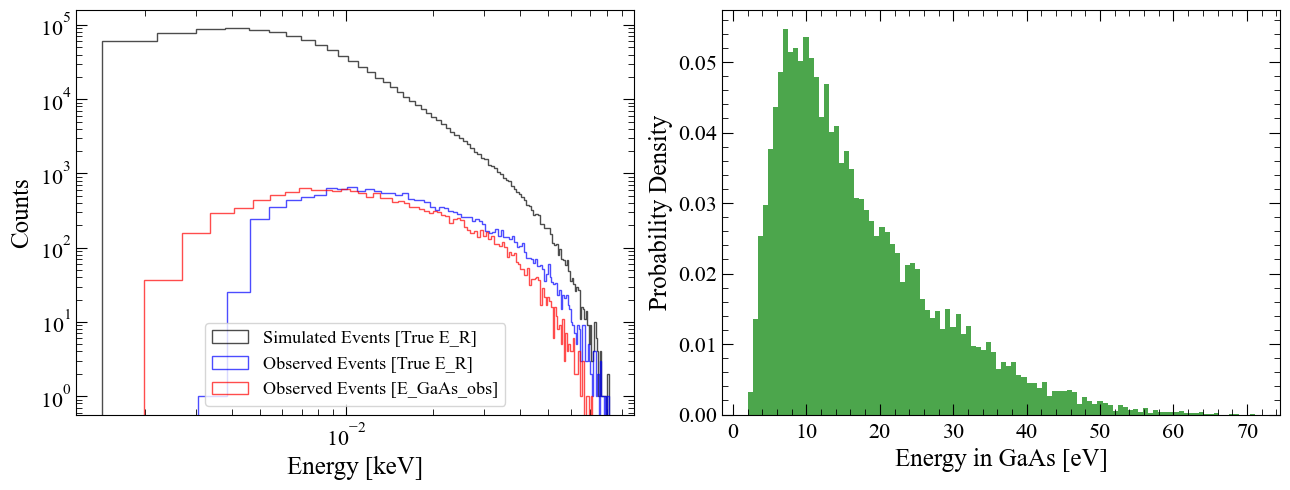

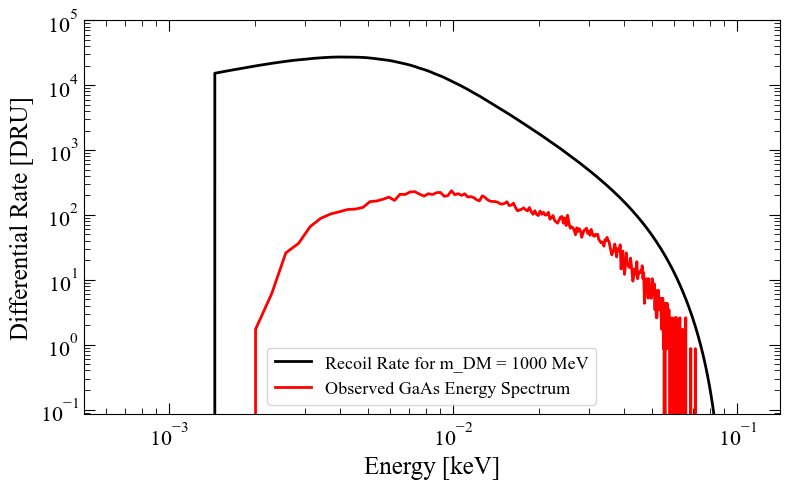

In [2]:
E_GaAs_2fold, dRdE_GaAs_2fold = darklim.detector.DM_spectrum_GaAs(m_DM_eV=1e9, sigma=1e-35, mediator='massive',
                     N_PDs = 1, E_th_PD = 0.183e-3 * 4, E_res_PD = 0.183e-3, E_th_GaAs = 0.282e-3 * 4, E_res_GaAs = 0.282e-3,
                     collection_efficiency=0.25, verbose=True, plot=True
                     )
R_2fold = np.trapz(dRdE_GaAs_2fold, E_GaAs_2fold) * 2.72e-3

E_GaAs_3fold, dRdE_GaAs_3fold = darklim.detector.DM_spectrum_GaAs(m_DM_eV=1e9, sigma=1e-35, mediator='massive',
                     N_PDs = 2, E_th_PD = 0.183e-3 * 4, E_res_PD = 0.183e-3, E_th_GaAs = 0.282e-3 * 4, E_res_GaAs = 0.282e-3,
                     collection_efficiency=0.25, verbose=True, plot=True
                     )

R_3fold = np.trapz(dRdE_GaAs_3fold, E_GaAs_3fold) * 2.72e-3

print(f'2-fold rate: {R_2fold:.3e} per day')
print(f'3-fold rate: {R_3fold:.3e} per day')

 .... Loading files for GaAs
Loaded GaAs_mermin.dat for epsilon in electron regime
electronic ELF taken or calculated from Y. Tu, C. Kwei and C. Tung,Angular and energy dependences of the surface excitation parameter for semiconducting iii–v compounds, Surface Science601(2007) 865.
phonon ELF taken or calculated from H.M. Lawler and E.L. Shirley, Anharmonic effects on infrared spectra of GaAs and gap:  First-principles calculations, Phys. Rev. B70(2004) 245209 and E.D. Palik, Gallium arsenide (gaas), in Handbook of Optical Constants of Solids, E.D. Palik, ed.,pp. 429–443, Elsevier (1985).
Loaded GaAs_epsphonon_data10K.dat for epsilon in phonon regime
Warning! Atomic Migdal calculation not present
Warning! Momentum dependent Zion for Migdal calculation not loaded. Using Z - number of valence electrons.
Loaded /home/vvelan/DarkELF/darkelf/../data/GaAs/Ga_pDoS.dat for partial densities of states
Loaded /home/vvelan/DarkELF/darkelf/../data/GaAs/As_pDoS.dat for partial densities of states
L

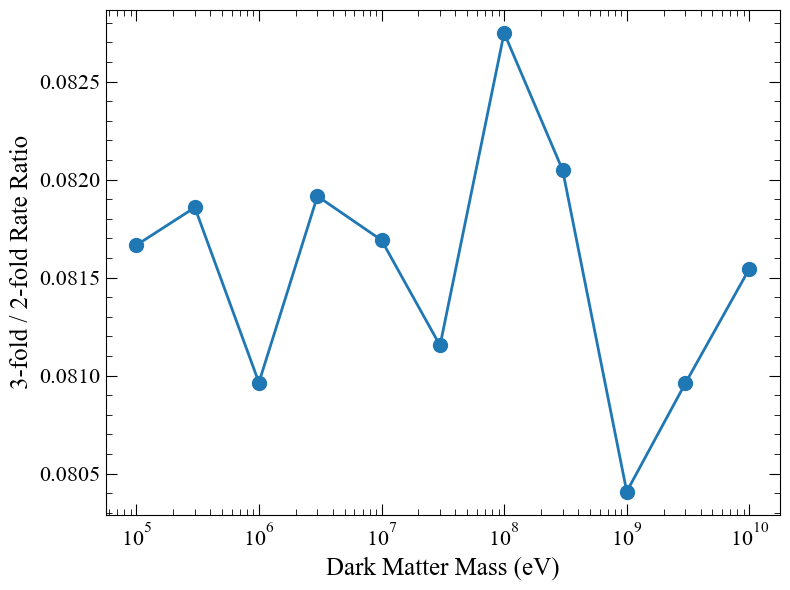

In [3]:
fig, ax = plt.subplots(figsize=(8, 6))

masses_eV = np.array([1e5, 3e5, 1e6, 3e6, 1e7, 3e7, 1e8, 3e8, 1e9, 3e9, 1e10])
ratio_arr = np.zeros_like(masses_eV)

for i, mass in enumerate(masses_eV):
    E_GaAs_2fold, dRdE_GaAs_2fold = darklim.detector.DM_spectrum_GaAs(m_DM_eV=1e9, sigma=1e-35, mediator='massive',
                        N_PDs = 1, E_th_PD = 0.183e-3 * 4, E_res_PD = 0.183e-3, E_th_GaAs = 0.282e-3 * 4, E_res_GaAs = 0.282e-3,
                        collection_efficiency=0.25, verbose=False, plot=False
                        )
    R_2fold = np.trapz(dRdE_GaAs_2fold, E_GaAs_2fold) * 2.72e-3

    E_GaAs_3fold, dRdE_GaAs_3fold = darklim.detector.DM_spectrum_GaAs(m_DM_eV=1e9, sigma=1e-35, mediator='massive',
                        N_PDs = 2, E_th_PD = 0.183e-3 * 4, E_res_PD = 0.183e-3, E_th_GaAs = 0.282e-3 * 4, E_res_GaAs = 0.282e-3,
                        collection_efficiency=0.25, verbose=False, plot=False
                        )

    R_3fold = np.trapz(dRdE_GaAs_3fold, E_GaAs_3fold) * 2.72e-3

    ratio_arr[i] = R_3fold / R_2fold
    print(i)
    
ax.plot(masses_eV, ratio_arr, marker='o')

ax.set_xscale('log')
ax.set_xlabel('Dark Matter Mass (eV)')
ax.set_ylabel('3-fold / 2-fold Rate Ratio')

fig.tight_layout()
fig.show()

# NR Signal Spectra

Mean recoil energy: 6.448 eV, std 5.834 eV
Mean number of electron-hole pairs: 0.129, variance 0.148
Fraction of events with at least 0.65 eV in Photodetector: 0.017
Mean recoil energy: 6.441 eV, std 5.831 eV
Mean number of electron-hole pairs: 0.129, variance 0.148
Fraction of events with at least 0.65 eV in Photodetector: 0.000
2-fold rate: 2.844e+04 per kg per day
3-fold rate: 4.514e+02 per kg per day


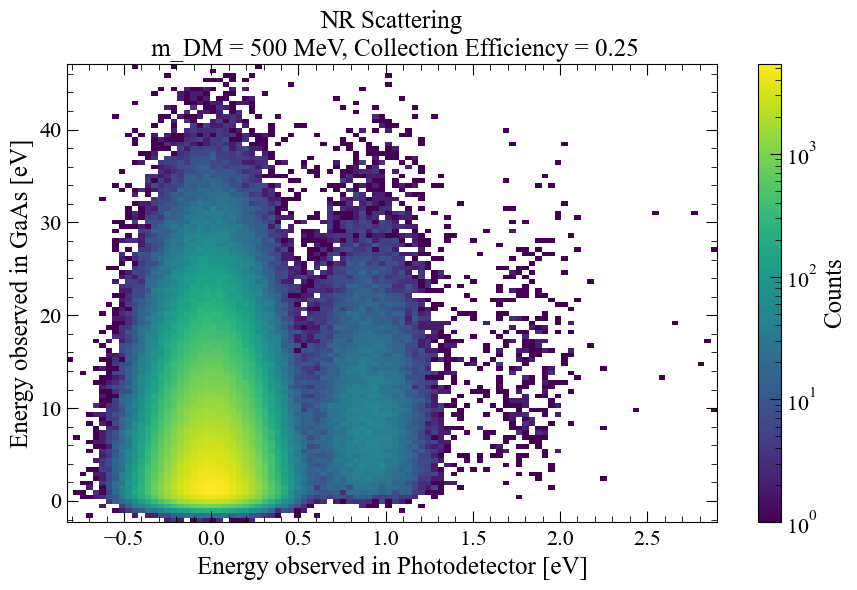

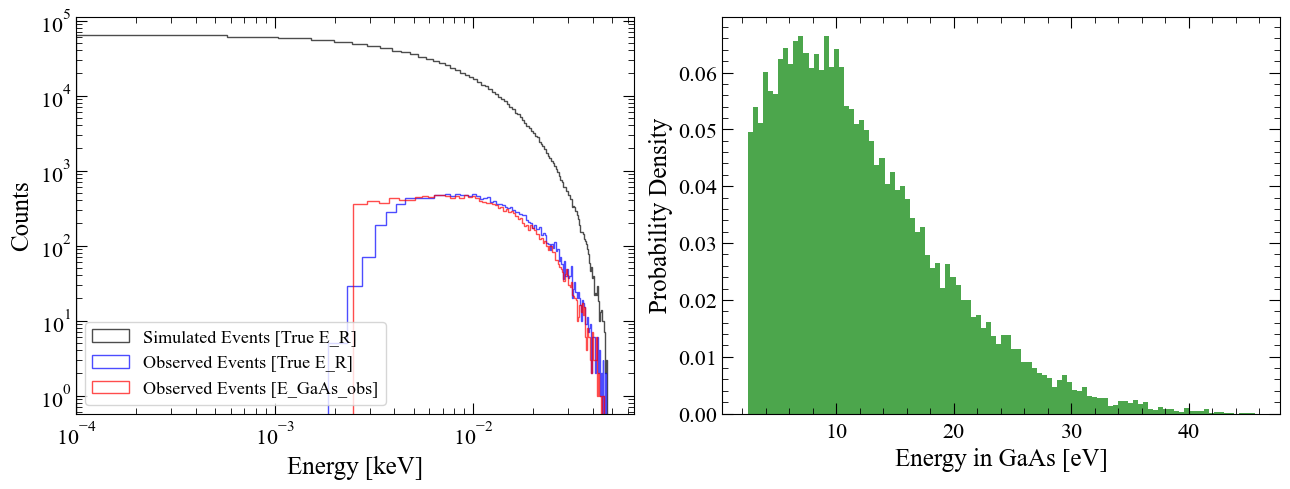

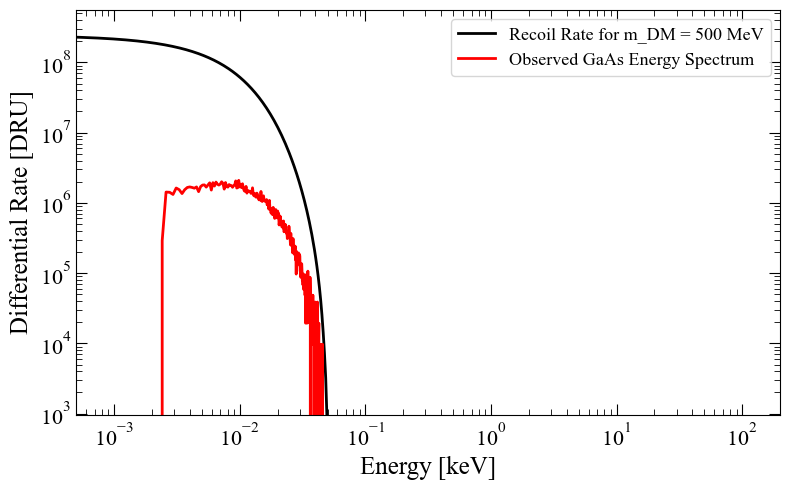

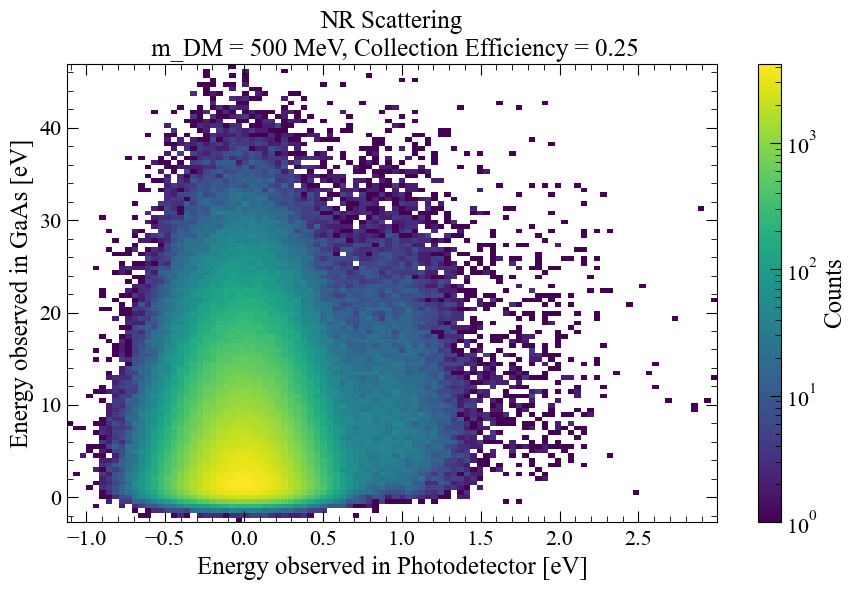

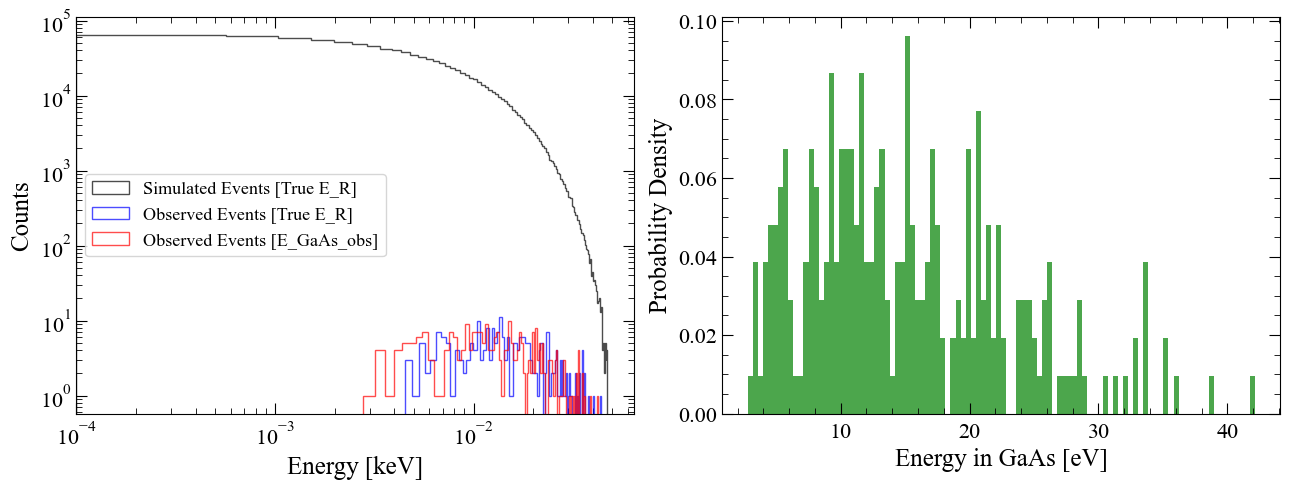

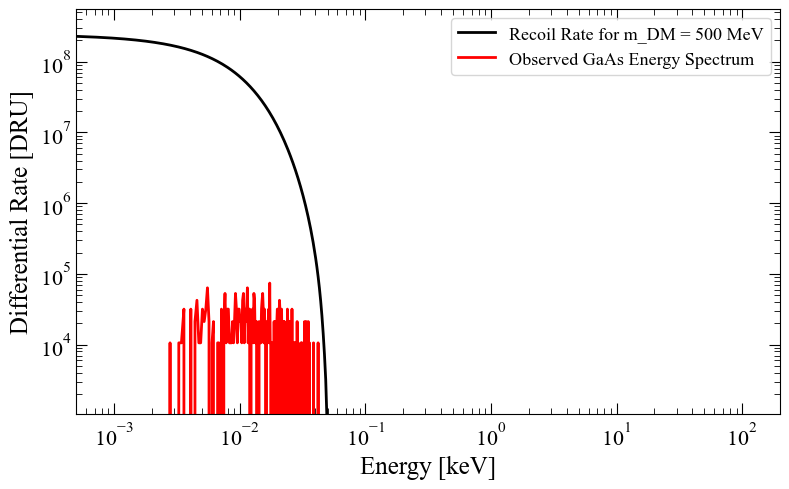

In [5]:
E_GaAs_2fold, dRdE_GaAs_2fold = darklim.detector.DM_spectrum_GaAs(m_DM_eV=500e6, sigma=1e-35, mediator='NR',
                     N_PDs = 1, E_th_PD = 0.163e-3 * 4, E_res_PD = 0.163e-3, E_th_GaAs = 0.617e-3 * 4, E_res_GaAs = 0.617e-3,
                     collection_efficiency=0.25, verbose=True, plot=True
                     )
R_2fold = np.trapz(dRdE_GaAs_2fold, E_GaAs_2fold)

E_GaAs_3fold, dRdE_GaAs_3fold = darklim.detector.DM_spectrum_GaAs(m_DM_eV=500e6, sigma=1e-35, mediator='NR',
                     N_PDs = 2, E_th_PD = 0.163e-3 * 4, E_res_PD = 0.163e-3, E_th_GaAs = 0.617e-3 * 4, E_res_GaAs = 0.617e-3,
                     collection_efficiency=0.25, verbose=True, plot=True
                     )

R_3fold = np.trapz(dRdE_GaAs_3fold, E_GaAs_3fold)

print(f'2-fold rate: {R_2fold:.3e} per kg per day')
print(f'3-fold rate: {R_3fold:.3e} per kg per day')

In [ ]:
E_keV = np.geomspace(1e-5, 1e2, 1000)
dRdE_DRU = darklim.detector.drde(E_keV, 0.5, 1e-35, 'GaAs')

R_DM = np.trapz(dRdE_DRU, E_keV)

print(f'Real DM Rate: {R_DM:.3e} per kg per day')

Real DM Rate: 1.731e+06 per kg per day
2-fold rate: 2.844e+04 per kg per day
3-fold rate: 4.514e+02 per kg per day


Real DM Rate: 1.731e+06 per kg per day


In [10]:
4.5e2/1.73e6

0.00026011560693641616

# Signal Detection Efficiency

Finished ER, 2-fold, LCE = 0.25
Finished ER, 3-fold, LCE = 0.25
Finished NR, 2-fold, LCE = 0.25
Finished NR, 3-fold, LCE = 0.25


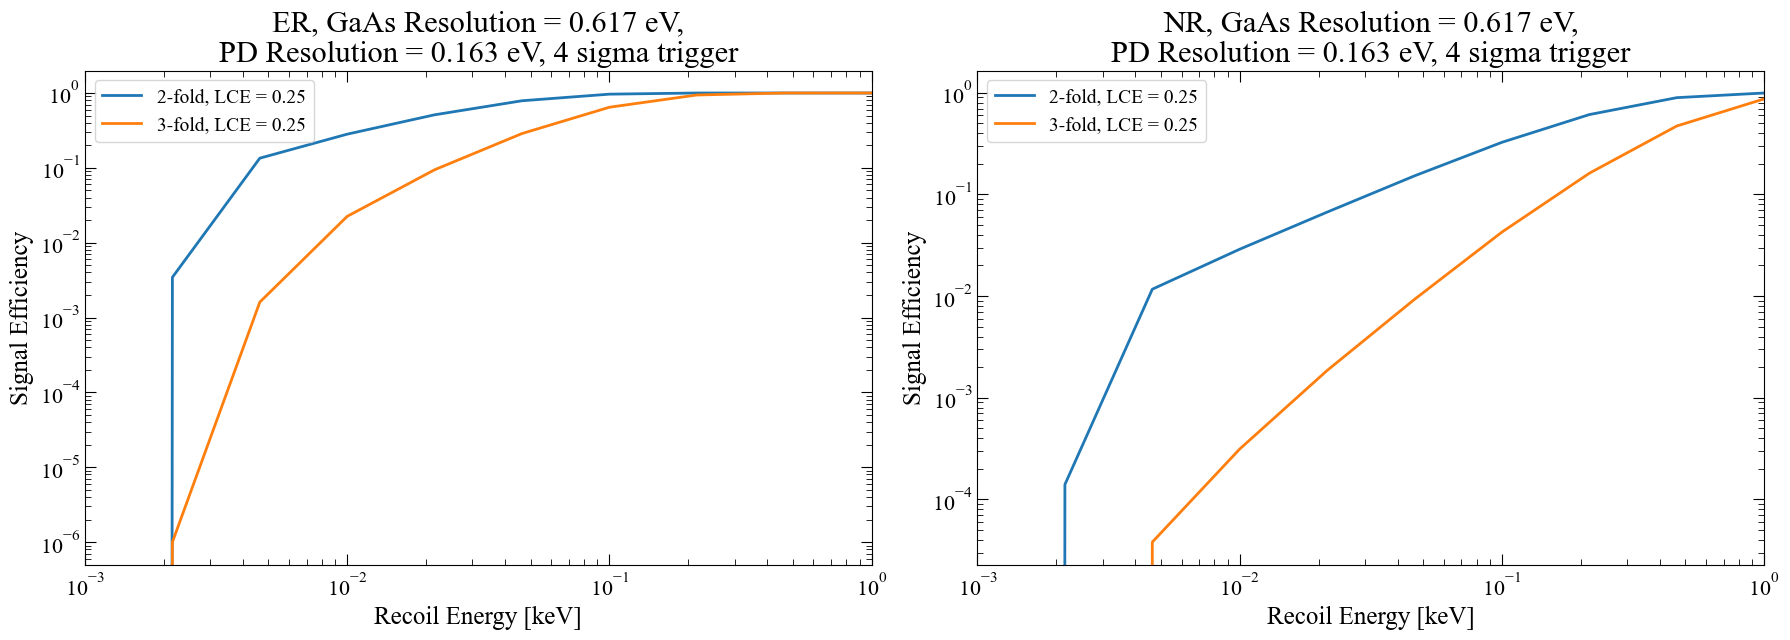

In [5]:
# Probably not changing these
GaAs_QE = 0.6
GaAs_gamma_energy = 0.9e-3  # Energy of recombined e-h photons in keV

# Containers to hold signal efficiency
E_keV_arr = np.geomspace(0.001, 1, 10)

# We may want to change these
n_sigma = 4

fig, ax = plt.subplots(1, 2, figsize=(18, 6.5))

for axi, pt in enumerate(['ER', 'NR']):
    
    if pt == 'NR':
        GaAs_energy_resolution = 0.617e-3  # Energy resolution in keV
        PD_energy_resolution = 0.163e-3
    else:
        GaAs_energy_resolution = 0.617e-3
        PD_energy_resolution = 0.163e-3

    for fold, color in zip([2, 3], ['C0', 'C1']):
        for LCE, ls in zip([0.25], ['-', '--', ':']):
            
            eps_arr = np.zeros_like(E_keV_arr)
            label = f'{fold}-fold, LCE = {LCE:.2f}'

            for i, E_keV in enumerate(E_keV_arr):

                E_GaAs_obs_keV, E_PD_A_obs_keV, E_PD_B_obs_keV, detected = \
                    darklim.detector.monoenergetic_sim_GaAs(
                        E_keV, recoil = pt, N_PDs = (fold - 1),
                        E_th_PD = PD_energy_resolution * n_sigma, E_res_PD = PD_energy_resolution,
                        E_th_GaAs = GaAs_energy_resolution * n_sigma, E_res_GaAs = GaAs_energy_resolution,
                        collection_efficiency=LCE, GaAs_QE=GaAs_QE, GaAs_gamma_energy=GaAs_gamma_energy,
                        rng=np.random.default_rng(12345), n_sim = 1_000_000, verbose=False
                    )

                eps_arr[i] = np.sum(detected) / len(detected)

            ax[axi].plot(E_keV_arr, eps_arr, label=label, color=color, ls=ls)
            ax[axi].set_title(f'{pt}, GaAs Resolution = {GaAs_energy_resolution*1e3:.3f} eV,\nPD Resolution = {PD_energy_resolution*1e3:.3f} eV, {n_sigma:.0f} sigma trigger', fontsize=22)
            print(f'Finished {pt}, {label}')


ax[0].set_xlabel('Recoil Energy [keV]')
ax[0].set_ylabel('Signal Efficiency')
#ax[0].set_title('ER Scattering')
ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].legend(loc='upper left', fontsize=14)
ax[0].set_xlim([E_keV_arr[0], E_keV_arr[-1]])

ax[1].set_xlabel('Recoil Energy [keV]')
ax[1].set_ylabel('Signal Efficiency')
#ax[1].set_title('NR Scattering')
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[1].legend(loc='upper left', fontsize=14)
ax[1].set_xlim([E_keV_arr[0], E_keV_arr[-1]])


fig.tight_layout()
fig.show()


In [6]:
6 * darklim.detector.Lindhard(6e-3) / 4.5

N = np.random.poisson(0.115, 1_000_000)

In [7]:
sum(N > 1) / len(N)

0.006092